# Gaussian (fBm) experiment — theta scaling analysis

Compares two fits on the same M=8 fractional Gaussian data (H=0.5, genuinely
Gaussian): order-2-only potentials vs order-2 + order-4 (Mod2 Real/Imag).

For jointly Gaussian data, Wick's theorem says order-4's raw correlation
`E[|Wx_s1|^2 |Wx_s2|^2]` is fully determined by second-order structure — it
should vanish for well-separated scale pairs, with a small nonzero floor only
for near-diagonal pairs (filter-bank overlap, not real structure). H=0.5
(white noise increments) isolates that floor cleanly.

If order-4 isn't contributing, two things should hold: its coefficients are
statistically indistinguishable from 0 across seeds, and adding it to the fit
shouldn't shift order-2's own estimated values.


In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import matplotlib.pyplot as plt

# Notebook lives in gaussian_experiment/, mirroring run_SDE.py's own
# sys.path setup (see that file's module docstring for why this exact order
# matters: 'codes' and 'data' need to be importable both as packages and as
# bare top-level modules, since files under them cross-import each other
# both ways).
root = Path().resolve()
project_root = root.parent

for p in (root, project_root, project_root / 'codes', project_root / 'data'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from codes.sde_routines import *
from codes.utils import *
from codes.utils_experiment import *
from codes.check_moments import *
from codes.potentials_builder import *
from codes.filters_bank import *
from codes.check_potentials import *          # theta scaling / normalization toolkit
from codes.ortho_wavelet.ReadyToUseWavelets import *
from data.synthetic_data_generator import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('root:', root)


device: cuda
root: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/gaussian_experiment


## 1. Two fits: order-2-only vs order-2+order-4

Same M/J/Q/hurst/nt/n1/lam/regularization/n_subsample for both — only
`terms`/`label` differ, so any difference between them isolates the effect
of adding order-4.


In [2]:
J, Q, M = 3, 1, 8
hurst, intermittency = 0.5, 0.0
sigma, nt, n1, lam, regularization, n_subsample = 1.0, 400, 10000, 1e-06, 1e-5, 40

REAL_KEY = 'Scattering_Fourth_Order_Mod2_Real_Q1'
IMAG_KEY = 'Scattering_Fourth_Order_Mod2_Imag_Q1'
COMPLEX_NAME = 'Scattering_Fourth_Order_Mod2_Q1'

common = dict(J=J, Q=Q, hurst=hurst, intermittency=intermittency, sigma=sigma, nt=nt, n1=n1,
              lam=lam, regularization=regularization, n_subsample=n_subsample,
              interpolant='Cos', batch_size=None, timestamp='', force_rerun=False)

args_order2 = SimpleNamespace(**common, terms=['Scattering_Second_Order'], label='gaussian_d8', seed=0)
args_order2_4 = SimpleNamespace(**common, terms=['Scattering_Second_Order', REAL_KEY, IMAG_KEY],
                                 label='test_regularization', seed=0)

SEED_RANGE = range(200, 299)


## 2. Potentials per fit

Built once per fit from its own `terms` — deterministic given J/Q, shared by
every seed in that fit's sweep.


In [3]:
filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)

potentials_order2 = get_1d_potentials(args_order2.terms, J, filters, Q,
                                       filters_Q=filters_Q, filters_Phi=filters_Phi,
                                       scalar_param=None, parallel=False)
potentials_order2_4 = get_1d_potentials(args_order2_4.terms, J, filters, Q,
                                         filters_Q=filters_Q, filters_Phi=filters_Phi,
                                         scalar_param=None, parallel=False)

## 3. Load both seed sweeps, paired on shared seeds

For each fit and each seed: resolve + load the saved run, regenerate that
seed's `x1` only if the run actually resolved, evaluate `m_k`/`std_k`. Keeps
one representative seed's `xt` per fit for section 8. Only seeds present in
*both* fits are kept, so later comparisons are a true paired comparison.


In [4]:
def load_fit_sweep(args_fit, potentials_fit, M, seed_range, root, device):
    theta_final, theta_reg_final, mk, stdk, x1_all = {}, {}, {}, {}, {}
    missing, missing_reg = [], []
    xt_example, xt_example_seed, x1_example = None, None, None

    for seed in seed_range:
        args_seed = SimpleNamespace(**{**vars(args_fit), 'seed': seed})
        config_prefix = build_config_name(args_seed, M, coarse_grained=False, include_timestamp=False)
        resolved_config = resolve_config_for_loading(root, config_prefix)
        if resolved_config is None:
            missing.append(seed)
            continue

        loaded = try_load_experiment(root, resolved_config, device)
        if loaded is None or not loaded.get('loaded', False):
            missing.append(seed)
            continue

        theta_t_seed = loaded['theta_t']
        theta_reg_seed = loaded['Theta_reg']
        if theta_reg_seed is None:
            missing_reg.append(seed)
            continue

        # NOTE: load_synthetic_data('mrw', ...) is NOT reproducible from this
        # seed -- DataGeneratorBase.worker() (data/synthetic_data_generator.py)
        # calls np.random.seed(None) internally on every batch, unconditionally
        # (even at num_workers=1), which discards the seeding below. So x1_seed
        # here is *a* draw at these parameters, not *the* draw the fit saw --
        # regenerating it again later (e.g. in section 10) will NOT reproduce
        # this same array. Store it now (x1_all) and reuse it downstream
        # instead of regenerating, so every section is self-consistent with
        # what mk/stdk were actually computed from.
        torch.manual_seed(seed)
        np.random.seed(seed)
        raw = load_synthetic_data('mrw', args_fit.n1, M + 1, lam=args_fit.intermittency, H=args_fit.hurst).to(device)
        x1_seed = normalize(raw.diff(dim=-1)).to(device)

        theta_final[seed] = theta_t_seed[-1] if torch.is_tensor(theta_t_seed) else torch.as_tensor(theta_t_seed[-1])
        theta_reg_final[seed] = theta_reg_seed[-1] if torch.is_tensor(theta_reg_seed) else torch.as_tensor(theta_reg_seed[-1])
        mk[seed] = compute_mk(potentials_fit, x1_seed)
        stdk[seed] = compute_stdk(potentials_fit, x1_seed)
        x1_all[seed] = x1_seed.detach().cpu()   # kept for every seed (not just the example) -- see section 10

        if xt_example is None:   # keep one representative seed's samples, for section 7
            xt_example = loaded['xt'].detach().cpu()
            xt_example_seed = seed
            x1_example = x1_seed.detach().cpu()

    return dict(theta_final=theta_final, theta_reg_final=theta_reg_final, mk=mk, stdk=stdk,
                missing=missing, missing_reg=missing_reg, x1_all=x1_all,
                xt_example=xt_example, xt_example_seed=xt_example_seed, x1_example=x1_example)

sweep_order2 = load_fit_sweep(args_order2, potentials_order2, M, SEED_RANGE, root, device)
sweep_order2_4 = load_fit_sweep(args_order2_4, potentials_order2_4, M, SEED_RANGE, root, device)

seeds_common = sorted(set(sweep_order2['theta_final']) & set(sweep_order2_4['theta_final']))
print(f"order2-only: {len(sweep_order2['theta_final'])}/{len(list(SEED_RANGE))} seeds loaded")
print(f"order2+4:    {len(sweep_order2_4['theta_final'])}/{len(list(SEED_RANGE))} seeds loaded")
print(f"shared seeds usable for a paired comparison: {len(seeds_common)}")
if not seeds_common:
    raise RuntimeError("No seed overlap between the two sweeps -- pairing needs at least some shared seeds.")

def stack_for_seeds(sweep, key, seeds):
    return torch.stack([sweep[key][s] for s in seeds])

theta_all_order2       = stack_for_seeds(sweep_order2,   'theta_final',     seeds_common)
theta_reg_all_order2   = stack_for_seeds(sweep_order2,   'theta_reg_final', seeds_common)
theta_all_order2_4     = stack_for_seeds(sweep_order2_4, 'theta_final',     seeds_common)
theta_reg_all_order2_4 = stack_for_seeds(sweep_order2_4, 'theta_reg_final', seeds_common)

col_map_order2   = theta_column_map(potentials_order2,   theta_all_order2.shape[-1],   verbose=False)
col_map_order2_4 = theta_column_map(potentials_order2_4, theta_all_order2_4.shape[-1], verbose=False)

assert col_map_order2['Scattering_Second_Order'][1] == col_map_order2_4['Scattering_Second_Order'][1], (
    "Second_Order has a different coefficient count in the two fits -- check J/Q match."
)


Model MRW: generating data ...


100%|##########| 157/157 [00:00<00:00, 2931.00it/s]


Finished.
Model MRW: generating data ...


100%|##########| 157/157 [00:00<00:00, 3259.45it/s]


Finished.
Model MRW: generating data ...


...

Finished.
Model MRW: generating data ...


100%|##########| 157/157 [00:00<00:00, 3215.28it/s]


Finished.
Model MRW: generating data ...


100%|##########| 157/157 [00:00<00:00, 3190.93it/s]


Finished.
order2-only: 99/99 seeds loaded
order2+4:    99/99 seeds loaded
shared seeds usable for a paired comparison: 99


## Variance gain: MGD vs REG

Per coefficient, how much does regularization shrink variance across seeds?
If REG is smaller everywhere (or nearly), that justifies defaulting to REG.

In [5]:
theta_np_order2_4 = theta_all_order2_4.detach().cpu().numpy() if torch.is_tensor(theta_all_order2_4) else np.asarray(theta_all_order2_4)
var_mgd = theta_np_order2_4.var(axis=0, ddof=1)
theta_reg_np_order2_4 = theta_reg_all_order2_4.detach().cpu().numpy() if torch.is_tensor(theta_reg_all_order2_4) else np.asarray(theta_reg_all_order2_4)
var_reg = theta_reg_np_order2_4.var(axis=0, ddof=1)

gain = var_mgd / var_reg   # >1 means REG has smaller variance than MGD

# x/bar_colors built locally (not borrowed from the "Mean vs. variance" cell
# below) so this cell doesn't depend on running after it.
family_of_coef = np.empty(theta_np_order2_4.shape[-1], dtype=object)
for name, (start, dim) in col_map_order2_4.items():
    family_of_coef[start:start + dim] = name
family_colors = {'Scattering_Second_Order': 'tab:blue', REAL_KEY: 'tab:red', IMAG_KEY: 'tab:purple'}
bar_colors = [family_colors[f] for f in family_of_coef]
x = np.arange(theta_np_order2_4.shape[-1])

print(f"REG has smaller variance than MGD for {(gain > 1).mean():.1%} of coefficients")
print(f"variance gain (MGD var / REG var): median = {np.median(gain):.2f}x, "
      f"min = {gain.min():.2f}x, max = {gain.max():.2f}x")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, gain, color=bar_colors)
ax.axhline(1, color='black', ls='--', lw=1, label='no gain (MGD == REG)')
ax.set_yscale('log')
ax.set_xlabel('coefficient index')
ax.set_ylabel('variance gain\n(MGD var / REG var)')
ax.set_title('Variance reduction from regularization, per coefficient')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

REG has smaller variance than MGD for 100.0% of coefficients
variance gain (MGD var / REG var): median = 134.51x, min = 106.59x, max = 176.75x


## 4. Mean vs. variance per coefficient

Two bar charts, same coefficient-index x-axis, colored by family. A
coefficient only matters if it's away from zero in *both*. Nonzero mean but
near-zero std = constant across seeds, absorbed by `log Z` regardless of
its value — a second way a coefficient can fail to matter.

In [6]:
theta_np_order2_4 = theta_all_order2_4.detach().cpu().numpy() if torch.is_tensor(theta_all_order2_4) else np.asarray(theta_all_order2_4)
mean_all = theta_np_order2_4.mean(axis=0)
std_all = theta_np_order2_4.std(axis=0, ddof=1)

family_of_coef = np.empty(theta_np_order2_4.shape[-1], dtype=object)
for name, (start, dim) in col_map_order2_4.items():
    family_of_coef[start:start + dim] = name

family_colors = {'Scattering_Second_Order': 'tab:blue', REAL_KEY: 'tab:red', IMAG_KEY: 'tab:purple'}
bar_colors = [family_colors[f] for f in family_of_coef]
x = np.arange(len(mean_all))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(x, mean_all, color=bar_colors)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_yscale('symlog', linthresh=1e-4)
axes[0].set_ylabel('mean(theta)\nacross seeds')
axes[0].set_title('Mean vs. variance per coefficient (order2+4 fit)')
axes[0].legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in family_colors.values()],
               family_colors.keys(), fontsize=8, loc='upper right')

axes[1].bar(x, std_all, color=bar_colors, alpha=0.3)
axes[1].set_yscale('symlog', linthresh=1e-4)
axes[1].set_ylabel('std(theta)\nacross seeds')
axes[1].set_xlabel('coefficient index')

plt.tight_layout()
plt.show()


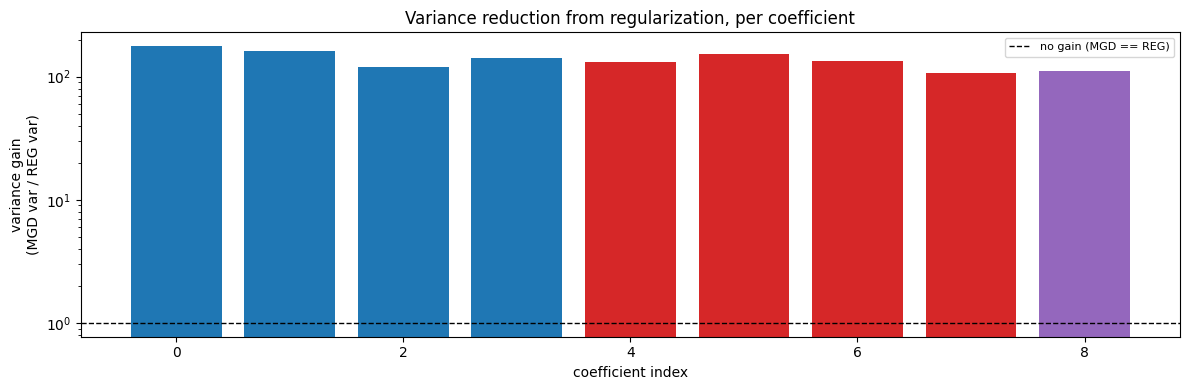

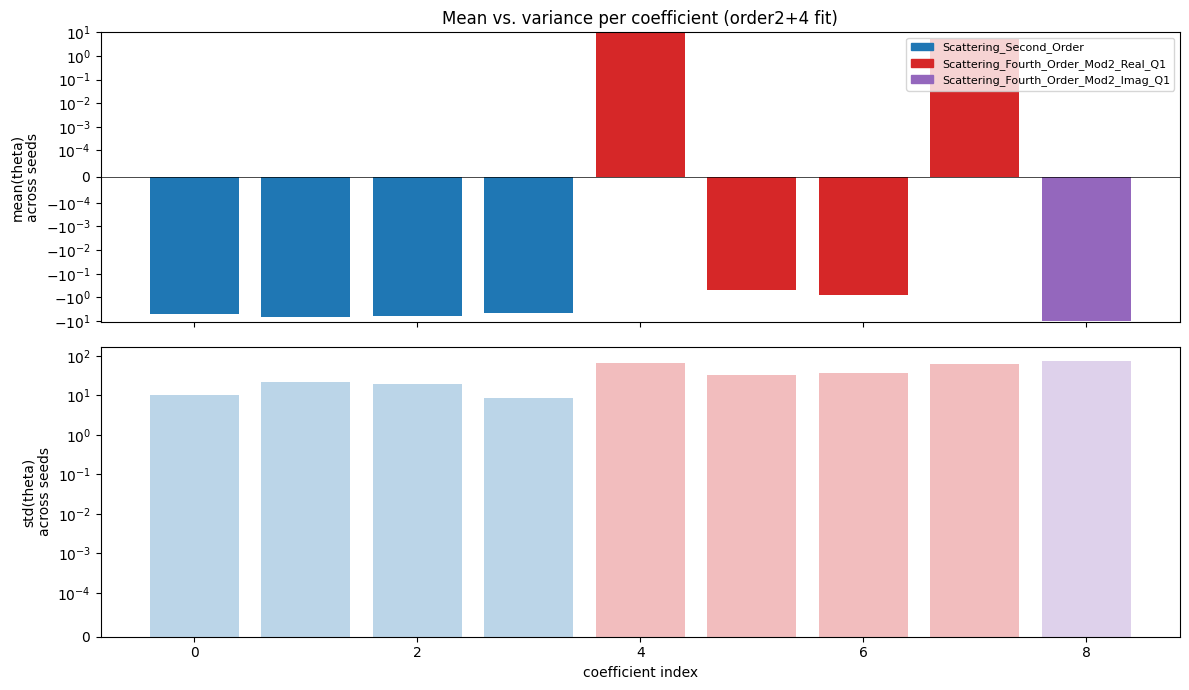

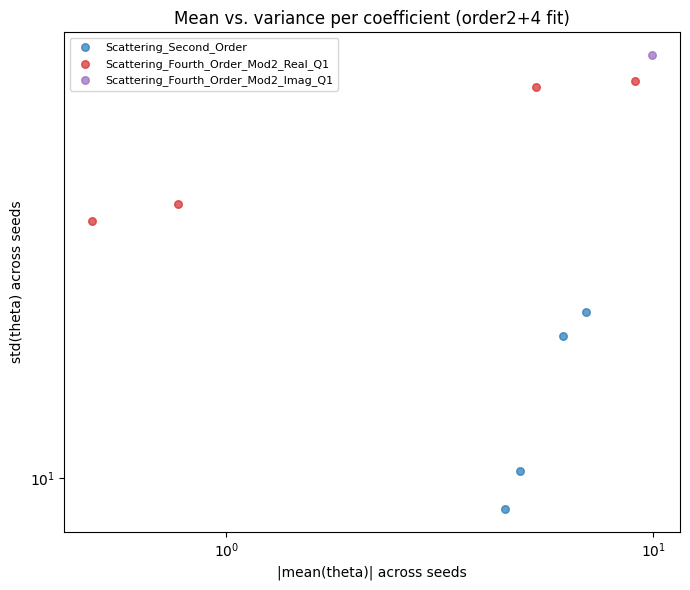

In [7]:
%matplotlib inline 
mean_all = theta_np_order2_4.mean(axis=0)
std_all = theta_np_order2_4.std(axis=0, ddof=1)

family_of_coef = np.empty(theta_np_order2_4.shape[-1], dtype=object)
for name, (start, dim) in col_map_order2_4.items():
    family_of_coef[start:start + dim] = name

family_colors = {'Scattering_Second_Order': 'tab:blue', REAL_KEY: 'tab:red', IMAG_KEY: 'tab:purple'}

plt.figure(figsize=(7, 6))
for name, color in family_colors.items():
    mask = family_of_coef == name
    plt.scatter(np.abs(mean_all[mask]), std_all[mask], color=color, alpha=0.7, label=name, s=30)
plt.xlabel('|mean(theta)| across seeds')
plt.ylabel('std(theta) across seeds')
plt.xscale('symlog', linthresh=1e-4)
plt.yscale('symlog', linthresh=1e-4)
plt.legend(fontsize=8)
plt.title('Mean vs. variance per coefficient (order2+4 fit)')
plt.tight_layout()
plt.show()

## 5. Regularization bias check

One representative seed (order-2+4 fit): does `Theta_reg` converge to
`theta_t` by `t_final`, or does it settle at a different value?


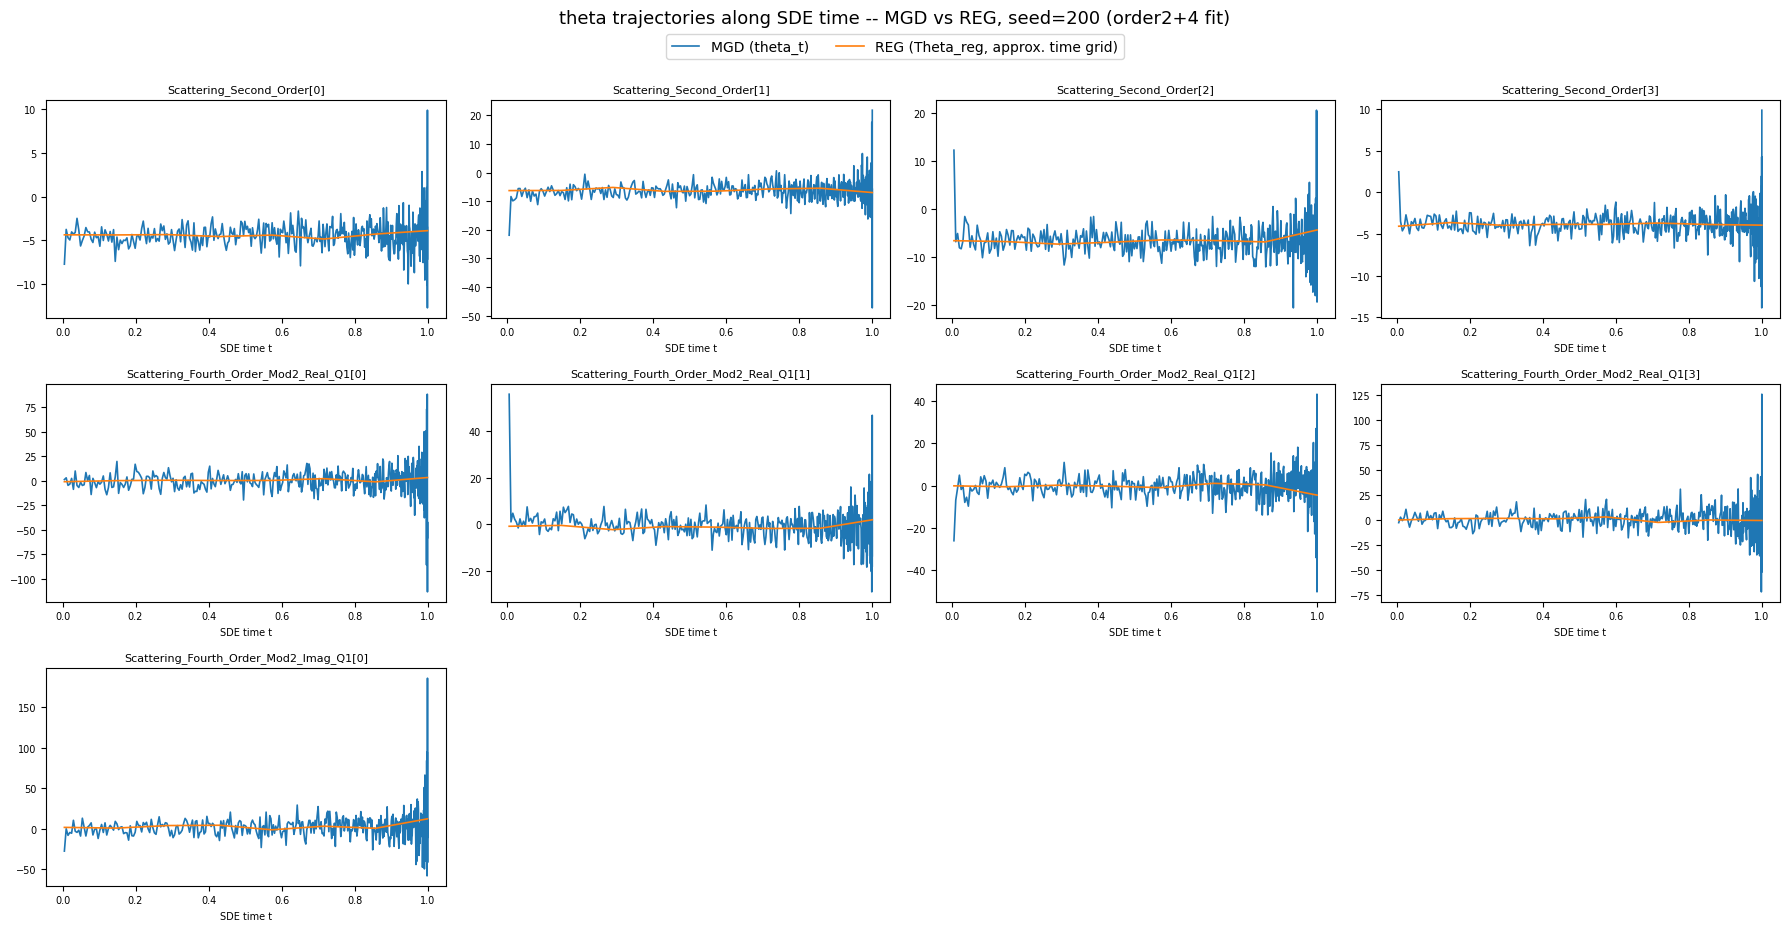

In [8]:
%matplotlib inline
import math

seed = 200  # pick a seed present in seeds_common

args_seed = SimpleNamespace(**{**vars(args_order2_4), 'seed': seed})
config_prefix = build_config_name(args_seed, M, coarse_grained=False, include_timestamp=False)
resolved_config = resolve_config_for_loading(root, config_prefix)
if resolved_config is None:
    raise FileNotFoundError(f"No saved run matches '{config_prefix}' for seed {seed}.")

loaded = try_load_experiment(root, resolved_config, device)
if loaded is None or not loaded.get('loaded', False):
    raise FileNotFoundError(f"Found '{resolved_config}' but failed to load it.")

theta_t_seed = loaded['theta_t']
theta_reg_seed = loaded['Theta_reg']
if theta_reg_seed is None:
    raise ValueError(f"Seed {seed}'s run has theta_t but no Theta_reg -- was it saved with regularization on?")

t_np = loaded['t'].cpu().numpy() if torch.is_tensor(loaded['t']) else np.asarray(loaded['t'])
theta_np = theta_t_seed.detach().cpu().numpy() if torch.is_tensor(theta_t_seed) else np.asarray(theta_t_seed)
theta_reg_np = theta_reg_seed.detach().cpu().numpy() if torch.is_tensor(theta_reg_seed) else np.asarray(theta_reg_seed)

n_t = theta_np.shape[0]
t_np = t_np[-n_t:]   # align t's tail with theta_t/Theta_reg

if theta_reg_np.shape[0] != t_np.shape[0]:
    # Theta_reg's own coarse time grid isn't saved for this run -- approximate,
    # evenly spaced between the same endpoints (see codes/utils.py load_t_reg).
    t_reg_np = np.linspace(t_np[0], t_np[-1], theta_reg_np.shape[0])
else:
    t_reg_np = t_np

n_features = theta_np.shape[-1]
col_map_bias = theta_column_map(potentials_order2_4, n_features, verbose=False)
coef_labels = [f'coef {k}' for k in range(n_features)]
for name, (start, dim) in col_map_bias.items():
    for j in range(dim):
        coef_labels[start + j] = f"{name}[{j}]"

ncols = 4
nrows = math.ceil(n_features / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows), squeeze=False)
axes = axes.flatten()

for k in range(n_features):
    ax = axes[k]
    ax.plot(t_np,     theta_np[:, k],     color='tab:blue',   lw=1.2, label='MGD (theta_t)')
    ax.plot(t_reg_np, theta_reg_np[:, k], color='tab:orange', lw=1.2, label='REG (Theta_reg, approx. time grid)')
    ax.set_title(coef_labels[k], fontsize=8)
    ax.set_xlabel('SDE time t', fontsize=7)
    ax.tick_params(labelsize=7)

for k in range(n_features, len(axes)):
    axes[k].axis('off')

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f'theta trajectories along SDE time -- MGD vs REG, seed={seed} (order2+4 fit)', fontsize=13, y=1.03)
fig.tight_layout()
plt.show()


## 6. theta2 shift between the two fits (paired)

Did adding order-4 change theta2's own estimate? Centered at 0 = no contamination.


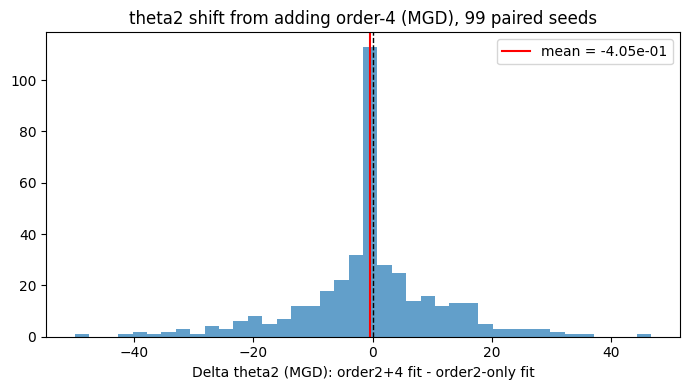

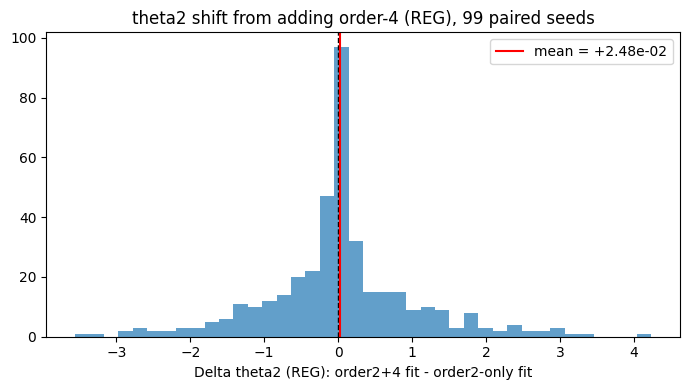

In [9]:
def plot_delta_theta2(theta_a, theta_b, seeds, title_suffix):
    start_a, dim_a = col_map_order2['Scattering_Second_Order']
    start_b, dim_b = col_map_order2_4['Scattering_Second_Order']
    t_a = (theta_a.detach().cpu().numpy() if torch.is_tensor(theta_a) else np.asarray(theta_a))[:, start_a:start_a + dim_a]
    t_b = (theta_b.detach().cpu().numpy() if torch.is_tensor(theta_b) else np.asarray(theta_b))[:, start_b:start_b + dim_b]
    delta = t_b - t_a
    plt.figure(figsize=(7, 4))
    plt.hist(delta.ravel(), bins=40, alpha=0.7)
    plt.axvline(0, color='black', ls='--', lw=1)
    plt.axvline(delta.mean(), color='red', lw=1.5, label=f'mean = {delta.mean():+.2e}')
    plt.xlabel(f'Delta theta2 ({title_suffix}): order2+4 fit - order2-only fit')
    plt.legend()
    plt.title(f'theta2 shift from adding order-4 ({title_suffix}), {len(seeds)} paired seeds')
    plt.tight_layout()
    plt.show()
    return delta

delta_theta2_mgd = plot_delta_theta2(theta_all_order2, theta_all_order2_4, seeds_common, 'MGD')
delta_theta2_reg = plot_delta_theta2(theta_reg_all_order2, theta_reg_all_order2_4, seeds_common, 'REG')

## 7. Order-4 significance check

Complements section 4 — mean only, contrasted against order-2 as the
"should be significant" baseline.


In [10]:
def significance_fraction(theta_arr, coef_mask):
    X = (theta_arr.detach().cpu().numpy() if torch.is_tensor(theta_arr) else np.asarray(theta_arr))[:, coef_mask]
    mean = X.mean(axis=0)
    sem = X.std(axis=0, ddof=1) / np.sqrt(X.shape[0])
    z = np.abs(mean) / (sem + 1e-30)
    return (z < 2).mean()

mask_order2 = family_of_coef == 'Scattering_Second_Order'
mask_order4 = ~mask_order2

print(f"Fraction of order-2 coefficients consistent with 0 (|z|<2): {significance_fraction(theta_all_order2_4, mask_order2):.1%}")
print(f"Fraction of order-4 coefficients consistent with 0 (|z|<2): {significance_fraction(theta_all_order2_4, mask_order4):.1%}")

Fraction of order-2 coefficients consistent with 0 (|z|<2): 0.0%
Fraction of order-4 coefficients consistent with 0 (|z|<2): 100.0%


## 8. Outlier events: ||x||^2 vs chi2(M)
H=0.5 fBm increments are i.i.d. Gaussian, so ||x||^2/sigma^2 ~ chi2(M) after normalize(). Breaks if H != 0.5 later.


chi2(8) rare threshold (top 1%): 20.090
P(rare) analytic                    = 0.0100
P(rare) real data                   = 0.0097
P(rare) generated, order2-only fit  = 0.0105
P(rare) generated, order2+4 fit     = 0.0093


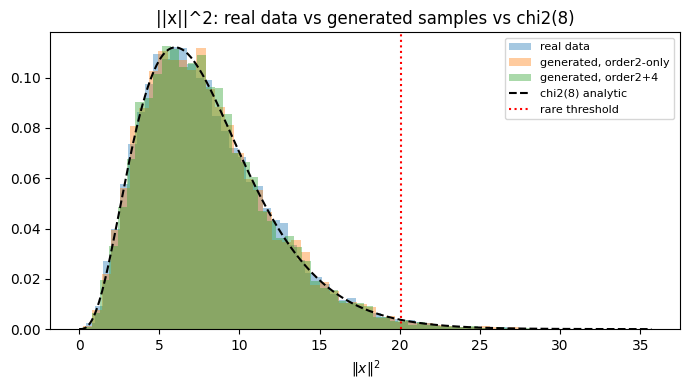

In [11]:
from scipy import stats

def norm_sq(x):
    x_np = x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)
    return (x_np.reshape(x_np.shape[0], -1) ** 2).sum(axis=-1)

RARE_QUANTILE = 0.99
chi2_M = stats.chi2(df=M)
rare_threshold = chi2_M.ppf(RARE_QUANTILE)

n2_real = norm_sq(sweep_order2_4['x1_example'])
n2_xt_order2 = norm_sq(sweep_order2['xt_example'])
n2_xt_order2_4 = norm_sq(sweep_order2_4['xt_example'])

print(f"chi2({M}) rare threshold (top {1 - RARE_QUANTILE:.0%}): {rare_threshold:.3f}")
print(f"P(rare) analytic                    = {1 - RARE_QUANTILE:.4f}")
print(f"P(rare) real data                   = {(n2_real > rare_threshold).mean():.4f}")
print(f"P(rare) generated, order2-only fit  = {(n2_xt_order2 > rare_threshold).mean():.4f}")
print(f"P(rare) generated, order2+4 fit     = {(n2_xt_order2_4 > rare_threshold).mean():.4f}")

grid = np.linspace(0, max(n2_real.max(), n2_xt_order2.max(), n2_xt_order2_4.max()), 400)
plt.figure(figsize=(7, 4))
plt.hist(n2_real, bins=60, density=True, alpha=0.4, label='real data')
plt.hist(n2_xt_order2, bins=60, density=True, alpha=0.4, label='generated, order2-only')
plt.hist(n2_xt_order2_4, bins=60, density=True, alpha=0.4, label='generated, order2+4')
plt.plot(grid, chi2_M.pdf(grid), 'k--', lw=1.5, label=f'chi2({M}) analytic')
plt.axvline(rare_threshold, color='red', ls=':', label='rare threshold')
plt.xlabel(r'$\|x\|^2$')
plt.legend(fontsize=8)
plt.title(f'||x||^2: real data vs generated samples vs chi2({M})')
plt.tight_layout()
plt.show()

## 9. Per-coefficient energy vs chi2(1) reference
Second_Order's forward is $|Wx_s|^2$ -- for Gaussian x1, $\theta_k*\phi_k(x)$ is a rescaled $\chi^2(1)$.

coefficient 0: c from mean = -1.6412e+00, c from var = 8.5751e-01 (agreement supports chi2(1))


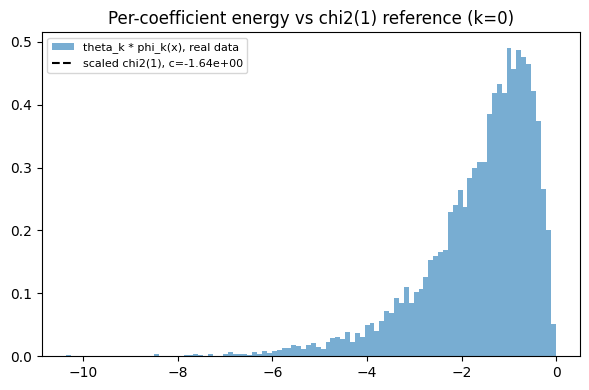

In [12]:

k_check = 0
pot_check = potentials_order2_4['Scattering_Second_Order']
phi_k_real = pot_check(sweep_order2_4['x1_example'])[:, k_check].detach().cpu().numpy()
theta_k = theta_np_order2_4[:, mask_order2][:, k_check].mean()
energy_k = theta_k * phi_k_real

c_from_mean = energy_k.mean()
c_from_var = np.sqrt(energy_k.var() / 2)
print(f"coefficient {k_check}: c from mean = {c_from_mean:.4e}, c from var = {c_from_var:.4e} (agreement supports chi2(1))")

grid = np.linspace(max(energy_k.min(), 1e-6), energy_k.max(), 400)
plt.figure(figsize=(6, 4))
plt.hist(energy_k, bins=100, density=True, alpha=0.6, label='theta_k * phi_k(x), real data')
plt.plot(grid, stats.chi2(df=1, scale=c_from_mean).pdf(grid), 'k--', label=f'scaled chi2(1), c={c_from_mean:.2e}')
plt.legend(fontsize=8)
plt.title(f'Per-coefficient energy vs chi2(1) reference (k={k_check})')
plt.tight_layout()
plt.show()


One thing in the existing notebook first. Cell 19 says "agreement supports χ²(1)", but its own printout disagrees: c from mean = -1.6008 against c from var = 8.2251e-01. The two are supposed to be equal. Working back from those two numbers, the implied effective degrees of freedom for coefficient 0 are about 3.8 rather than 1, so χ²(1) is the wrong reference there. Cell D below measures this for every coefficient.

★ Insight ─────────────────────────────────────

- For data N(0, I_M) the true log-density is −½‖x‖², whose variance is M/2. That is 4 for M=8, and I use it as a reference line. It is only exact if the potentials can represent ‖x‖², so read it as a rough reference and not a guaranteed target.
- Var(E) = Σ_k θ_k (Σθ)_k, where Σ = Cov[φ]. Each term c_k = Cov(θ_kφ_k, E) is a component's contribution, including its covariance with all the others. The terms sum exactly to Var(E), so family shares are exact and the cross-family term is explicit.
- Regenerating x1 per seed gives the full covariance Σ, not just mk and stdk. The per-coefficient std alone can't give the variance of a sum. The cell checks the regenerated means against the stored mk.
  ─────────────────────────────────────────────────

## 10. Energy E(x) = theta^T phi(x): setup
Mean of E is gauge-dependent (absorbed by log Z); Var(E) is not. Needs Cov[phi]
per seed, not just mk/stdk, because Var of a sum needs the cross terms.

In [13]:
to_np = lambda a: a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a)

def _idx(cm, name):
    s, d = cm[name]
    return np.arange(s, s + d)

D = theta_all_order2_4.shape[-1]
FAM = {'order 2': _idx(col_map_order2_4, 'Scattering_Second_Order'),
       'order 4': np.concatenate([_idx(col_map_order2_4, REAL_KEY), _idx(col_map_order2_4, IMAG_KEY)])}
FAM['total'] = np.arange(D)
FAM_COLOR = {'order 2': 'tab:blue', 'order 4': 'tab:red', 'total': 'tab:gray'}
assert FAM['order 2'][-1] + 1 == FAM['order 4'][0], "order-2 columns expected first, contiguous"

def phi_matrix(potentials, x):
    with torch.no_grad():
        f = [p(x) for p in potentials.values()]
    return torch.cat([g[:, None] if g.ndim == 1 else g for g in f], dim=1).double()

# Reuse each seed's x1 as stored by load_fit_sweep (section 3), rather than
# regenerating it here. load_synthetic_data('mrw', ...) is NOT reproducible
# from a seed -- DataGeneratorBase.worker() (data/synthetic_data_generator.py)
# calls np.random.seed(None) internally on every batch, unconditionally, so a
# second call at the same parameters draws an independent sample, not the
# same one. That's what broke the sanity check below when this cell used to
# regenerate: MU didn't match sweep_order2_4['mk'] because they came from two
# different draws, not because of a bug in the covariance computation.
MU, SIG = [], []
for seed in seeds_common:
    x1_s = sweep_order2_4['x1_all'][seed].to(device)
    Phi = phi_matrix(potentials_order2_4, x1_s)
    MU.append(Phi.mean(0).cpu().numpy())
    SIG.append(torch.cov(Phi.T).cpu().numpy())
MU, SIG = np.stack(MU), np.stack(SIG)          # (n_seeds, D), (n_seeds, D, D)
print(f"D = {D} coefficients, SIG = {SIG.nbytes / 1e6:.2f} MB")

# sanity check: MU must match the fit's own stored mk now, since both come
# from the exact same x1 (only float64-cast-for-Cov vs float32 differs).
np.testing.assert_allclose(MU[0], sweep_order2_4['mk'][seeds_common[0]], rtol=1e-4, atol=1e-6)

def embed_order2_only(theta):
    th = to_np(theta); s, d = col_map_order2['Scattering_Second_Order']
    out = np.zeros((th.shape[0], D)); out[:, FAM['order 2']] = th[:, s:s + d]
    return out

THETA = {
    ('order2-only', 'MGD'): embed_order2_only(theta_all_order2),
    ('order2-only', 'REG'): embed_order2_only(theta_reg_all_order2),
    ('order2+4',    'MGD'): to_np(theta_all_order2_4),
    ('order2+4',    'REG'): to_np(theta_reg_all_order2_4),
}

D = 9 coefficients, SIG = 0.06 MB


## 11. Mean and variance of E per family

reference Var(E) if the fit recovers the true Gaussian log-density: M/2 = 4

order2-only order 2  E mean =    -3.973 ±   0.233   Var(E) =    4.0326 ±   0.4537
order2+4    order 2  E mean =    -3.926 ±   0.491   Var(E) =    4.0340 ±   0.9585
order2+4    order 4  E mean =    -0.024 ±   0.220   Var(E) =    0.1391 ±   0.1205
order2+4    total    E mean =    -3.950 ±   0.315   Var(E) =    4.0803 ±   0.4545


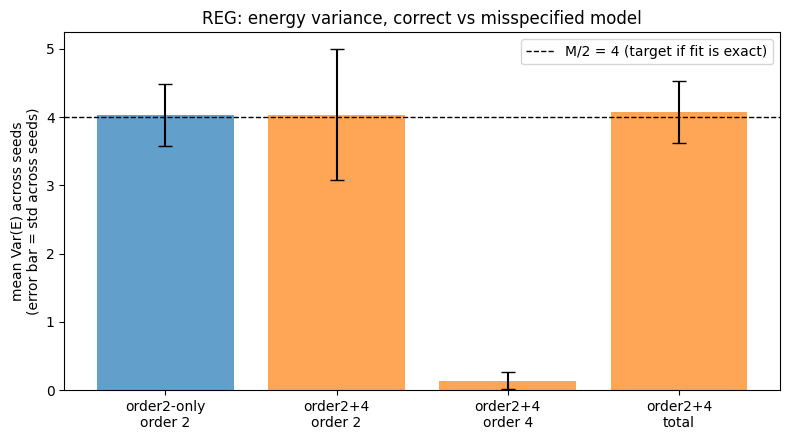

In [14]:
## 11. Var(E) per family, REG only -- correct (order2-only) vs misspecified (order2+4)
#
# Var(E) for one seed = how much the energy E(x) = theta.phi(x) varies ACROSS
# THAT SEED'S ~n1 DATA SAMPLES (uses that seed's own theta and covariance).
# It is a variance over data, not over seeds.
#
# We then have ~n_seeds such numbers (one per seed). The bar below shows
# their MEAN (the actual answer to "does REG get the right variance?") with
# an error bar = std across seeds (how stable that estimate is) -- not a
# boxplot, to avoid mixing "variance of energy" with "spread of an estimate".
def family_energy_stats(theta_all):
    out = {}
    for fam, idx in FAM.items():
        th = theta_all[:, idx]
        out[fam] = (np.einsum('sk,sk->s', th, MU[:, idx]),                          # E[E]
                    np.einsum('sk,skl,sl->s', th, SIG[:, idx][:, :, idx], th))      # Var(E)
    return out

STATS = {key: family_energy_stats(th) for key, th in THETA.items()}
VAR_REF = M / 2      # Var(-||x||^2/2) for x ~ N(0, I_M); rough reference, see markdown
print(f"reference Var(E) if the fit recovers the true Gaussian log-density: M/2 = {VAR_REF:g}\n")
for (fit, kind), st in STATS.items():
    if kind != 'REG':          # MGD dropped -- REG is the one we trust/use
        continue
    for fam in (['order 2'] if fit == 'order2-only' else list(FAM)):
        mean, var = st[fam]
        print(f"{fit:11s} {fam:8s} E mean = {mean.mean():+9.3f} ± {mean.std(ddof=1):7.3f}"
              f"   Var(E) = {var.mean():9.4f} ± {var.std(ddof=1):8.4f}")

groups = [
    ('order2-only\norder 2', STATS[('order2-only', 'REG')]['order 2'][1]),
    ('order2+4\norder 2',    STATS[('order2+4',    'REG')]['order 2'][1]),
    ('order2+4\norder 4',    STATS[('order2+4',    'REG')]['order 4'][1]),
    ('order2+4\ntotal',      STATS[('order2+4',    'REG')]['total'][1]),
]
x = np.arange(len(groups))
means = [g[1].mean() for g in groups]
stds = [g[1].std(ddof=1) for g in groups]
colors = ['tab:blue', 'tab:orange', 'tab:orange', 'tab:orange']   # order2-only vs order2+4

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.7)
ax.axhline(VAR_REF, color='k', ls='--', lw=1, label=f'M/2 = {VAR_REF:g} (target if fit is exact)')
ax.set_xticks(x); ax.set_xticklabels([g[0] for g in groups])
ax.set_ylabel('mean Var(E) across seeds\n(error bar = std across seeds)')
ax.set_title('REG: energy variance, correct vs misspecified model')
ax.legend()
plt.tight_layout(); plt.show()

total contribution, order 2 = 3.9876   order 4 = 0.0927   (sum = mean Var(E))


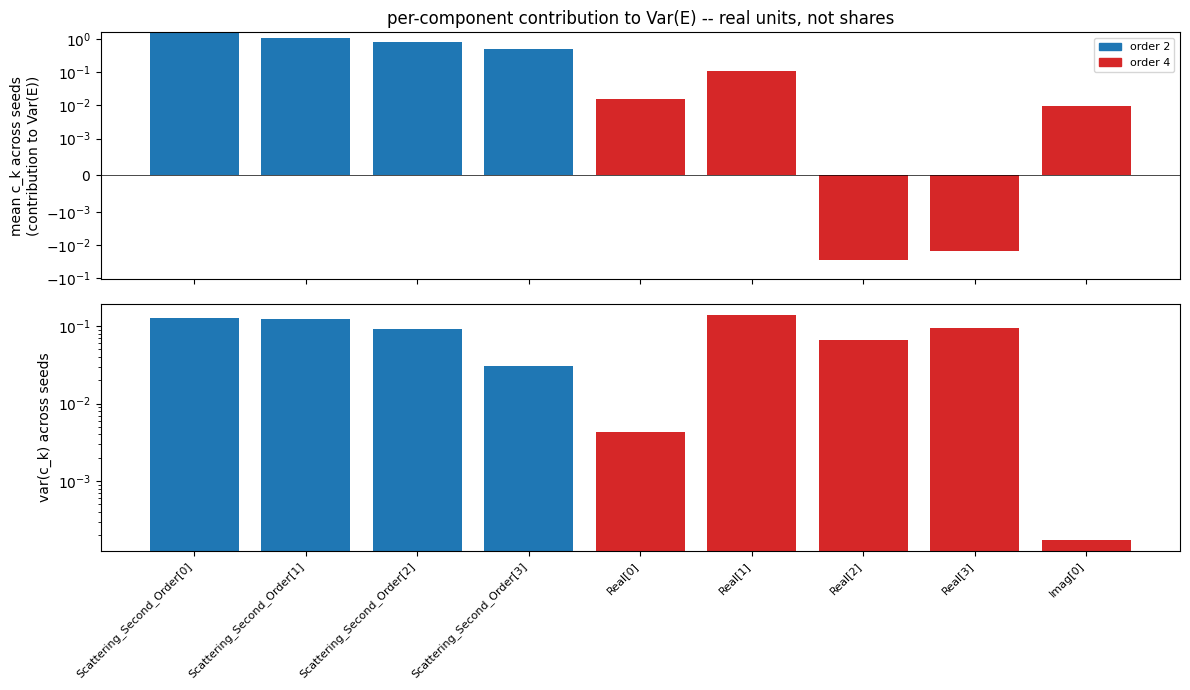

In [15]:
## 12. Where does Var(E) come from? c_k = Cov(theta_k phi_k, E), sums exactly to Var(E)
x = np.arange(D)
bar_colors = [FAM_COLOR['order 2'] if k in set(FAM['order 2']) else FAM_COLOR['order 4'] for k in x]

coef_labels = [f'coef {k}' for k in x]
for name, (start, dim) in col_map_order2_4.items():
    for j in range(dim):
        coef_labels[start + j] = f"{name.split('_')[-2]}[{j}]" if 'Q1' in name else f"{name}[{j}]"

def component_contributions(theta_all):
    return theta_all * np.einsum('skl,sl->sk', SIG, theta_all)   # c_k per seed, real units (not normalized)

th = THETA[('order2+4', 'REG')]
contrib = component_contributions(th)   # (n_seeds, D) -- c_k, sums to Var(E) per seed, real units

mean_c = contrib.mean(0)
var_c = contrib.var(0, ddof=1)

print(f"total contribution, order 2 = {mean_c[FAM['order 2']].sum():.4f}   "
      f"order 4 = {mean_c[FAM['order 4']].sum():.4f}   (sum = mean Var(E))")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(x, mean_c, color=bar_colors)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_yscale('symlog', linthresh=1e-3)   # c_k can be negative (cross terms)
axes[0].set_ylabel('mean c_k across seeds\n(contribution to Var(E))')
axes[0].set_title('per-component contribution to Var(E) -- real units, not shares')

axes[1].bar(x, var_c, color=bar_colors)
axes[1].set_yscale('log')                       # var_c is always >= 0
axes[1].set_xticks(x); axes[1].set_xticklabels(coef_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('var(c_k) across seeds')

axes[0].legend([plt.Rectangle((0, 0), 1, 1, color=FAM_COLOR[f]) for f in ('order 2', 'order 4')],
               ['order 2', 'order 4'], fontsize=8)
plt.tight_layout(); plt.show()

effective dof of order-2 components (chi2(1) -> 1): [3.74 3.55 2.   1.  ]
MGD: Var(E) / sum_k Var(e_k) = 0.48 ± 0.24   (>1: correlated components add variance, <1: they cancel)
REG: Var(E) / sum_k Var(e_k) = 1.24 ± 0.25   (>1: correlated components add variance, <1: they cancel)


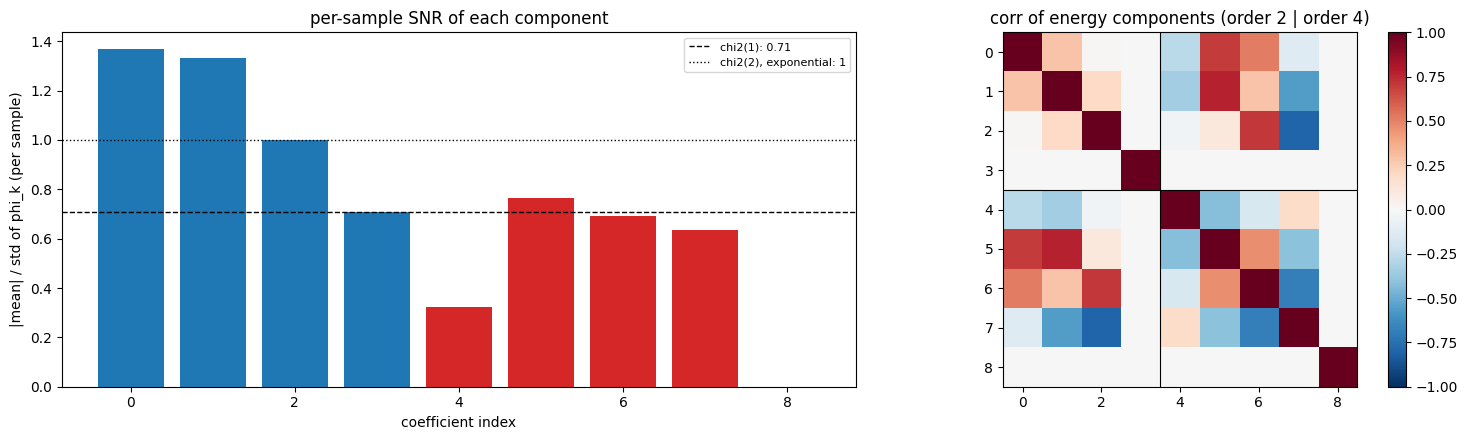

In [16]:
## 13. Single components: per-sample SNR / effective dof, and energy-component correlations
m_k = MU.mean(0)
s_k = np.sqrt(np.einsum('skk->sk', SIG)).mean(0)
snr = np.abs(m_k) / s_k              # theta-independent: theta_k cancels in |mean|/std of theta_k*phi_k
nu_eff = 2 * snr[FAM['order 2']] ** 2   # scaled chi2(nu): mean^2/var = nu/2
print("effective dof of order-2 components (chi2(1) -> 1):", np.round(nu_eff, 2))

th_bar = THETA[('order2+4', 'MGD')].mean(0)
S_mean = SIG.mean(0); sd = np.sqrt(np.diag(S_mean))
corr = S_mean / np.outer(sd, sd) * np.outer(np.sign(th_bar), np.sign(th_bar))   # corr(theta_k phi_k, theta_l phi_l)

for kind in ('MGD', 'REG'):
    th = THETA[('order2+4', kind)]
    indep = (th ** 2 * np.einsum('skk->sk', SIG)).sum(1)      # variance if components were uncorrelated
    infl = STATS[('order2+4', kind)]['total'][1] / indep
    print(f"{kind}: Var(E) / sum_k Var(e_k) = {infl.mean():.2f} ± {infl.std(ddof=1):.2f}   "
          f"(>1: correlated components add variance, <1: they cancel)")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw=dict(width_ratios=[1.3, 1]))
axes[0].bar(x, snr, color=bar_colors)
axes[0].axhline(1 / np.sqrt(2), color='k', ls='--', lw=1, label='chi2(1): 0.71')
axes[0].axhline(1.0, color='k', ls=':', lw=1, label='chi2(2), exponential: 1')
axes[0].set_xlabel('coefficient index'); axes[0].set_ylabel('|mean| / std of phi_k (per sample)')
axes[0].set_title('per-sample SNR of each component'); axes[0].legend(fontsize=8)

n2 = len(FAM['order 2'])
im = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].axvline(n2 - 0.5, color='k', lw=0.8); axes[1].axhline(n2 - 0.5, color='k', lw=0.8)
axes[1].set_title('corr of energy components (order 2 | order 4)')
fig.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

--- order2-only fit (seed 200) ---
  order 2  mean real -1.3169 gen -1.3212 (z=-0.1)   var real 12.0265 gen 11.6697 (z=-1.0)
--- order2+4 fit (seed 200) ---
  order 2  mean real +3.1153 gen +3.1702 (z=+1.1)   var real 12.0162 gen 11.7196 (z=-0.9)
  order 4  mean real -2.2731 gen -2.2674 (z=+0.1)   var real 7.4392 gen 7.7223 (z=+0.5)
  total    mean real +0.8423 gen +0.9027 (z=+1.2)   var real 13.7790 gen 13.8406 (z=+0.1)


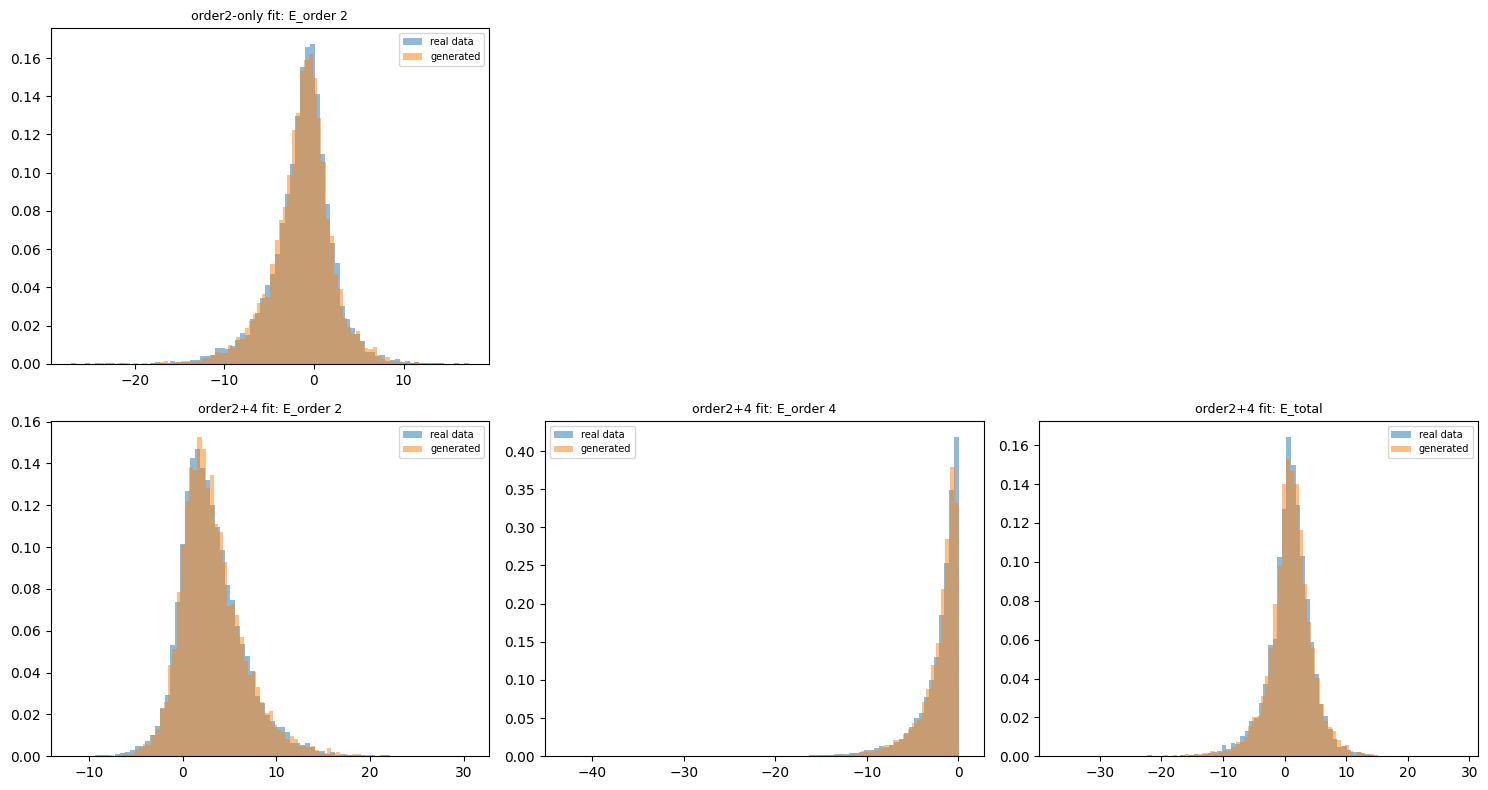

In [17]:
## 14. Real vs generated: energy mean/variance per family (example seed of each fit)
def phi_np(potentials, x, like):
    return phi_matrix(potentials, x.to(device).reshape(-1, *like.shape[1:])).cpu().numpy()

def moments(e):
    m, v = e.mean(), e.var(ddof=1)
    return m, v, ((e - m) ** 4).mean() / v ** 2, e.size      # mean, var, kurtosis, n

EXAMPLES = {
    'order2-only fit': (sweep_order2,   potentials_order2,
                        {'order 2': _idx(col_map_order2, 'Scattering_Second_Order')}),
    'order2+4 fit':    (sweep_order2_4, potentials_order2_4,
                        {'order 2': FAM['order 2'], 'order 4': FAM['order 4'], 'total': FAM['total']}),
}
fig, axes = plt.subplots(len(EXAMPLES), 3, figsize=(15, 8), squeeze=False)
for a in axes.ravel(): a.axis('off')
for r, (fit, (sw, pots, fams)) in enumerate(EXAMPLES.items()):
    seed_ex, x1_ex = sw['xt_example_seed'], sw['x1_example']
    theta = to_np(sw['theta_final'][seed_ex])
    Phi_real, Phi_gen = phi_np(pots, x1_ex, x1_ex), phi_np(pots, sw['xt_example'], x1_ex)
    print(f"--- {fit} (seed {seed_ex}) ---")
    for c, (fam, idx) in enumerate(fams.items()):
        e_r, e_g = Phi_real[:, idx] @ theta[idx], Phi_gen[:, idx] @ theta[idx]
        (m_r, v_r, k_r, n_r), (m_g, v_g, k_g, n_g) = moments(e_r), moments(e_g)
        z_mean = (m_g - m_r) / np.sqrt(v_r / n_r + v_g / n_g)
        z_var = (v_g - v_r) / np.sqrt(v_r ** 2 * (k_r - 1) / n_r + v_g ** 2 * (k_g - 1) / n_g)
        print(f"  {fam:8s} mean real {m_r:+.4f} gen {m_g:+.4f} (z={z_mean:+.1f})   "
              f"var real {v_r:.4f} gen {v_g:.4f} (z={z_var:+.1f})")
        ax = axes[r, c]; ax.axis('on')
        ax.hist(e_r, bins=80, density=True, alpha=0.5, label='real data')
        ax.hist(e_g, bins=80, density=True, alpha=0.5, label='generated')
        ax.set_title(f'{fit}: E_{fam}', fontsize=9); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

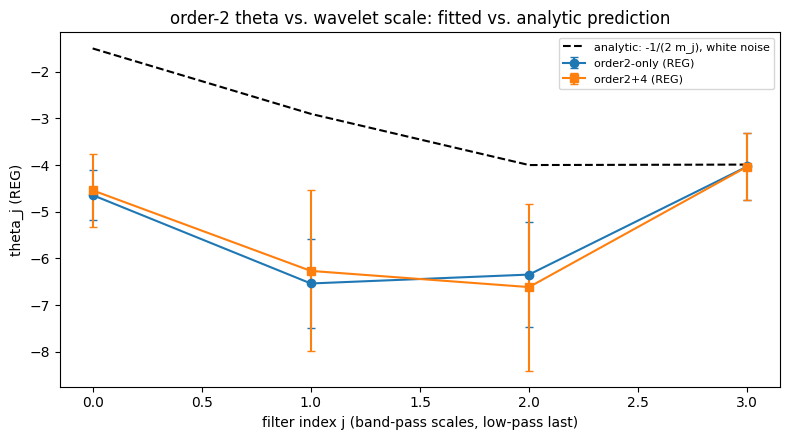

ratio fitted/analytic (order2-only):  [3.096 2.253 1.587 1.01 ]
ratio fitted/analytic (order2+4):     [3.028 2.16  1.654 1.011]


In [18]:
## Analytic reference: how theta_j scales with wavelet scale (order-2 only)
filt = filters_Q.detach().cpu().numpy()[0]              # (n_filters, M) filter, Fourier domain
m_analytic = (filt ** 2).mean(axis=-1)                   # Parseval; data_sigma ~= 1 after normalize()
theta_analytic = -1.0 / (2 * m_analytic)
order2_idx = FAM['order 2']
theta_order2only    = to_np(theta_reg_all_order2)                   # (n_seeds, n_order2), not padded# (n_seeds, n_order2)

theta_order2_in_mix = THETA[('order2+4', 'REG')][:, order2_idx]     # (n_seeds, n_order2)



j = np.arange(len(m_analytic))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(j, theta_order2only.mean(0), yerr=theta_order2only.std(0, ddof=1),
            fmt='o-', label='order2-only (REG)', color='tab:blue', capsize=3)
ax.errorbar(j, theta_order2_in_mix.mean(0), yerr=theta_order2_in_mix.std(0, ddof=1),
            fmt='s-', label='order2+4 (REG)', color='tab:orange', capsize=3)
ax.plot(j, theta_analytic, 'k--', label='analytic: -1/(2 m_j), white noise')
ax.set_xlabel('filter index j (band-pass scales, low-pass last)')
ax.set_ylabel('theta_j (REG)')
ax.set_title('order-2 theta vs. wavelet scale: fitted vs. analytic prediction')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("ratio fitted/analytic (order2-only): ", np.round(theta_order2only.mean(0) / theta_analytic, 3))
print("ratio fitted/analytic (order2+4):    ", np.round(theta_order2_in_mix.mean(0) / theta_analytic, 3))

logZ = 7.7558
Sigma_theta diagonal (should be ~1 if REG got it right): [1.111 1.111 1.111 1.111 1.111 1.111 1.111 1.111]
Sigma_theta off-diagonal max (should be ~0): 0.0799


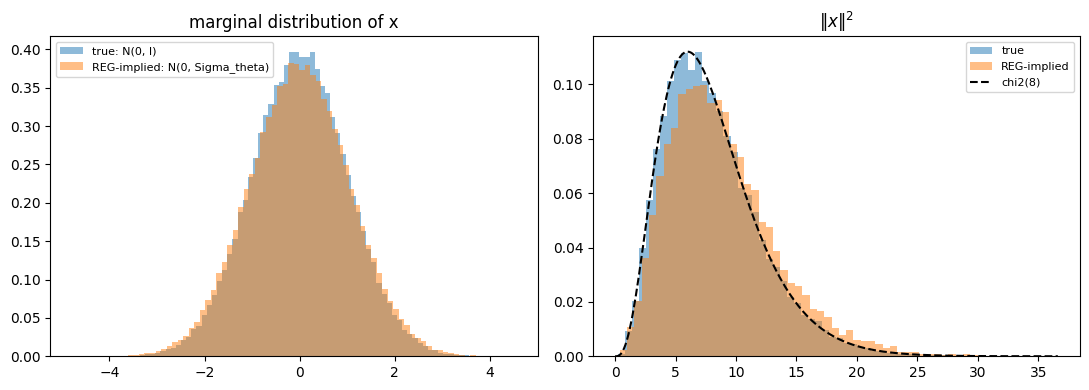

In [19]:
## Ground-truth comparison: N(0, I_M) [true data] vs N(0, Sigma_theta) [what REG learned]
n_new = 20000
x_true = np.random.multivariate_normal(np.zeros(M), np.eye(M), size=n_new)      # known analytic truth

seed_check = sweep_order2['xt_example_seed']
theta_reg_single = sweep_order2['theta_reg_final'][seed_check].cpu().numpy()     # order2-only, 4 coefficients

filt = filters_Q.detach().cpu().numpy()[0]
P = filt ** 2
Lambda_n = -2 * (theta_reg_single[:, None] * P).sum(axis=0) / M                 # the /M fix
F = np.fft.fft(np.eye(M)) / np.sqrt(M)
Lambda_time = np.real(F.conj().T @ np.diag(Lambda_n) @ F)
Sigma_theta = np.linalg.inv(Lambda_time)
logZ = 0.5 * M * np.log(2 * np.pi) - 0.5 * np.log(np.linalg.det(Lambda_time))
print(f"logZ = {logZ:.4f}")

x_mgd = np.random.multivariate_normal(np.zeros(M), Sigma_theta, size=n_new)     # what REG's theta implies

print("Sigma_theta diagonal (should be ~1 if REG got it right):", np.round(np.diag(Sigma_theta), 3))
print("Sigma_theta off-diagonal max (should be ~0):", np.round(np.abs(Sigma_theta - np.diag(np.diag(Sigma_theta))).max(), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(x_true.ravel(), bins=80, density=True, alpha=0.5, label='true: N(0, I)')
axes[0].hist(x_mgd.ravel(), bins=80, density=True, alpha=0.5, label='REG-implied: N(0, Sigma_theta)')
axes[0].legend(fontsize=8); axes[0].set_title('marginal distribution of x')

from scipy import stats
n2_true = (x_true ** 2).sum(-1)
n2_mgd = (x_mgd ** 2).sum(-1)
grid = np.linspace(0, max(n2_true.max(), n2_mgd.max()), 300)
axes[1].hist(n2_true, bins=60, density=True, alpha=0.5, label='true')
axes[1].hist(n2_mgd, bins=60, density=True, alpha=0.5, label='REG-implied')
axes[1].plot(grid, stats.chi2(df=M).pdf(grid), 'k--', label=f'chi2({M})')
axes[1].legend(fontsize=8); axes[1].set_title(r'$\|x\|^2$')
plt.tight_layout(); plt.show()